<a href="https://colab.research.google.com/github/hariprasad59/Intelligent-Book-Recommendations/blob/main/BookRecommendationSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df_basic = pd.read_csv("/content/drive/MyDrive/BookRecommendationSystem/Audible_Catlog.csv")
df_adv = pd.read_csv("/content/drive/MyDrive/BookRecommendationSystem/Audible_Catlog_Advanced_Features.csv")

print("Basic dataset shape:", df_basic.shape)
print("Advanced dataset shape:", df_adv.shape)

Basic dataset shape: (6368, 5)
Advanced dataset shape: (4464, 8)


In [47]:

df_basic.head()


,Book Name,Author,Rating,Number of Reviews,Price
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0


In [48]:
df_adv.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [49]:
print("Basic columns:\n", df_basic.columns)
print("\nAdvanced columns:\n", df_adv.columns)

Basic columns:
 Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='object')

Advanced columns:
 Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='object')


In [50]:
common_cols = set(df_basic.columns).intersection(set(df_adv.columns))
common_cols


{'Author', 'Book Name', 'Number of Reviews', 'Price', 'Rating'}

In [51]:
for df in [df_basic, df_adv]:
    df["Book Name"] = df["Book Name"].str.strip().str.lower()
    df["Author"] = df["Author"].str.strip().str.lower()


In [52]:
df_merged = pd.merge(
    df_basic,
    df_adv,
    on=["Book Name", "Author"],
    how="left",          # keep all books from basic dataset
    suffixes=("_basic", "_adv")
)

print("Merged dataset shape:", df_merged.shape)


Merged dataset shape: (6827, 11)


In [53]:
df_merged.isna().sum().sort_values(ascending=False).head(10)

,0
Number of Reviews_adv,2986
Description,2574
Price_adv,2568
Listening Time,2568
Ranks and Genre,2568
Rating_adv,2568
Number of Reviews_basic,684
Price_basic,4
Rating_basic,0
Book Name,0


In [54]:
df_merged.to_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_merged_raw.csv", index=False)

In [55]:
df = pd.read_csv("audible_merged_raw.csv")

print(df.shape)
df.head()

(6827, 11)


,Book Name,Author,Rating_basic,Number of Reviews_basic,Price_basic,Rating_adv,Number of Reviews_adv,Price_adv,Description,Listening Time,Ranks and Genre
0,think like a monk: the secret of how to harnes...,jay shetty,4.9,313.0,10080.0,4.9,371.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,ikigai: the japanese secret to a long and happ...,héctor garcía,4.6,3658.0,615.0,4.6,3682.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,the subtle art of not giving a f*ck: a counter...,mark manson,4.4,20174.0,10378.0,4.4,20306.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,atomic habits: an easy and proven way to build...,james clear,4.6,4614.0,888.0,4.6,4678.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,life's amazing secrets: how to find balance an...,gaur gopal das,4.6,4302.0,1005.0,4.6,4308.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [56]:
df.isna().sum().sort_values(ascending=False)

,0
Number of Reviews_adv,2986
Description,2574
Price_adv,2568
Listening Time,2568
Ranks and Genre,2568
Rating_adv,2568
Number of Reviews_basic,684
Price_basic,4
Rating_basic,0
Book Name,0


In [57]:
df["Final_Rating"] = df["Rating_basic"].combine_first(df["Rating_adv"])
df["Final_Price"] = df["Price_basic"].combine_first(df["Price_adv"])
df["Final_Reviews"] = df["Number of Reviews_basic"].combine_first(df["Number of Reviews_adv"])


In [58]:
df["Description"] = df["Description"].fillna("")


In [59]:
df["Listening Time"] = df["Listening Time"].fillna("unknown")
df["Ranks and Genre"] = df["Ranks and Genre"].fillna("unknown")


In [60]:
df["Final_Reviews"] = df["Final_Reviews"].fillna(0)


In [61]:
df["Final_Price"] = df["Final_Price"].fillna(df["Final_Price"].median())


In [62]:
cols_to_drop = [
    "Rating_basic", "Rating_adv",
    "Price_basic", "Price_adv",
    "Number of Reviews_basic", "Number of Reviews_adv"
]

df.drop(columns=cols_to_drop, inplace=True)

In [63]:
df.isna().sum().sort_values(ascending=False)

,0
Book Name,0
Author,0
Description,0
Listening Time,0
Ranks and Genre,0
Final_Rating,0
Final_Price,0
Final_Reviews,0


In [64]:
import re

def extract_genres(text):
    if pd.isna(text):
        return []

    text = text.lower()

    # Remove rankings like "#123 in ..."
    text = re.sub(r"#\d+.*?(,|$)", "", text)

    # Remove percentages and star ratings
    text = re.sub(r"\d+\s*star|\(\d+%\)|\d+%", "", text)

    # Split by commas
    parts = text.split(",")

    # Keep only meaningful genre words
    clean_genres = []
    for p in parts:
        p = p.strip()
        if len(p) > 3 and not any(x in p for x in ["audible", "see top", "free"]):
            clean_genres.append(p.title())

    return clean_genres


In [65]:
df["Clean_Genres"] = df["Ranks and Genre"].apply(extract_genres)


In [66]:
df[["Ranks and Genre", "Clean_Genres"]].head(5)


,Ranks and Genre,Clean_Genres
0,",#1 in Audible Audiobooks & Originals (See Top...",[]
1,",#2 in Audible Audiobooks & Originals (See Top...",[]
2,",#3 in Audible Audiobooks & Originals (See Top...",[]
3,",#5 in Audible Audiobooks & Originals (See Top...",[]
4,",#6 in Audible Audiobooks & Originals (See Top...",[]


Clean_Genres
Unknown                            2568
Thriller & Mystery (Books)           63
Body & Spirit                        43
Folk Tales & Myths For Children      16
History & Criticism                  11
Nutrition & Healthy Eating           10
Scottish & Welsh Literature           8
Irish                                 8
Tv & Video Game Tie-In Fiction        7
Technology & Medicine (Books)         7
Name: count, dtype: int64


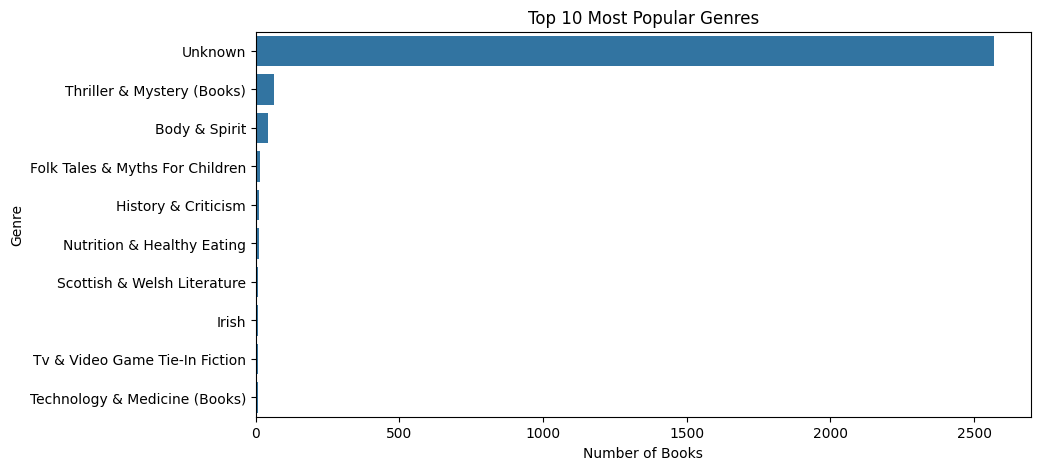

In [67]:
#EDA
#1.What are the most popular genres in the dataset?
genres_exploded = df["Clean_Genres"].explode()
top_genres = genres_exploded.value_counts().head(10)
print(top_genres)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Most Popular Genres")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.show()


Author
tracy abell          5.0
vasant lad           5.0
vella day            5.0
werner heidemann     5.0
paul halpern         5.0
heidi lemon          5.0
gregory r. lanier    5.0
michiel baas         5.0
peter altman         5.0
pauline rowson       5.0
Name: Final_Rating, dtype: float64


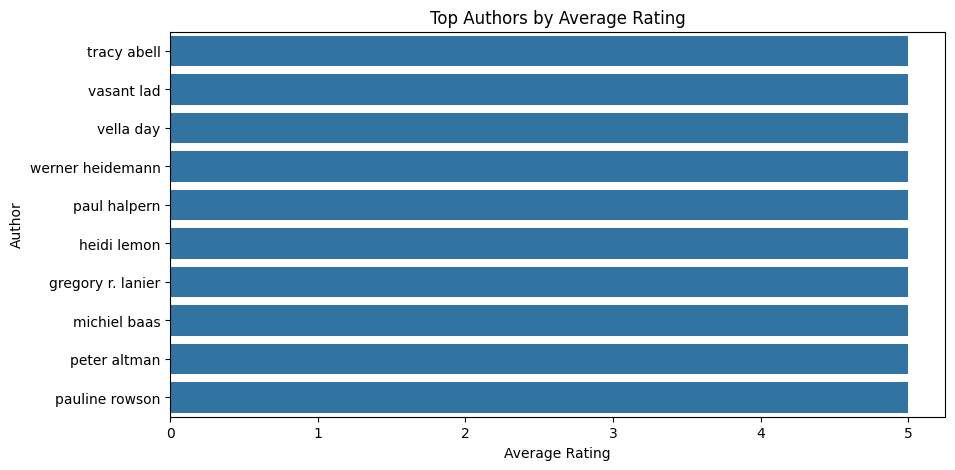

In [68]:
#2.What are the most popular genres in the dataset?
top_authors = (df.groupby("Author")["Final_Rating"].mean().sort_values(ascending=False).head(10))
print(top_authors)
plt.figure(figsize=(10,5))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top Authors by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Author")
plt.show()

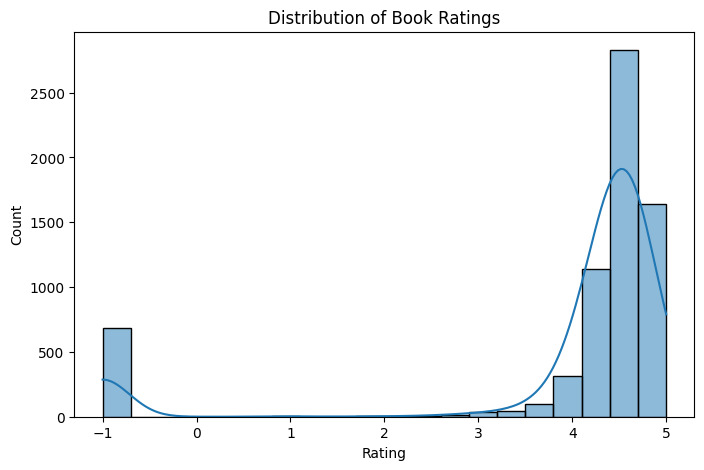

In [69]:
# 3. Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Final_Rating"], bins=20, kde=True)
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

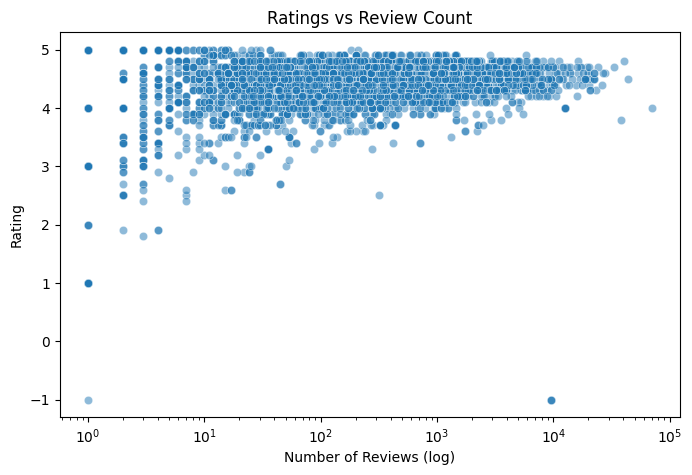

In [70]:
# 4. Rating vs Review Count
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Final_Reviews"], y=df["Final_Rating"], alpha=0.5)
plt.xscale("log")
plt.title("Ratings vs Review Count")
plt.xlabel("Number of Reviews (log)")
plt.ylabel("Rating")
plt.show()

In [71]:
# Q5: Books clustered by descriptions
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_text = tfidf.fit_transform(df["Description"])

kmeans = KMeans(n_clusters=8, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_text)

print("\nSample clustered books:")
print(df[["Book Name", "Author", "Cluster"]].head(10))


Sample clustered books:
                                           Book Name              Author  \
0  think like a monk: the secret of how to harnes...          jay shetty   
1  ikigai: the japanese secret to a long and happ...       héctor garcía   
2  the subtle art of not giving a f*ck: a counter...         mark manson   
3  atomic habits: an easy and proven way to build...         james clear   
4  life's amazing secrets: how to find balance an...      gaur gopal das   
5                           extraordinary leadership        robin sharma   
6                                            sapiens   yuval noah harari   
7                                            sapiens   yuval noah harari   
8                   the intelligent investor rev ed.     benjamin graham   
9  rich dad poor dad: what the rich teach their k...  robert t. kiyosaki   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  
5        0  
6        2  
7        2  
8        2  
9       

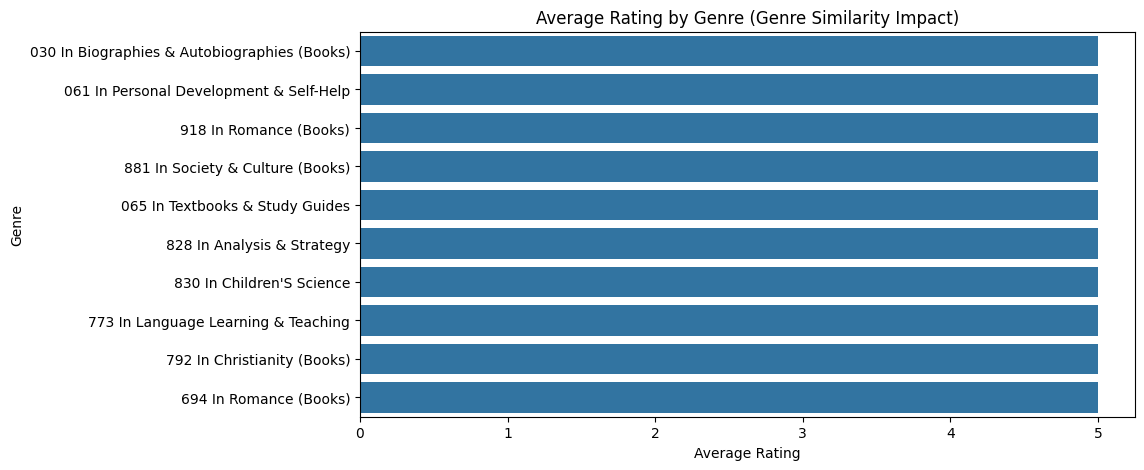

In [72]:
# Q7: Genre similarity effect on recommendations
genre_similarity = (
    df.explode("Clean_Genres")
      .groupby("Clean_Genres")["Final_Rating"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=genre_similarity.values, y=genre_similarity.index)
plt.title("Average Rating by Genre (Genre Similarity Impact)")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

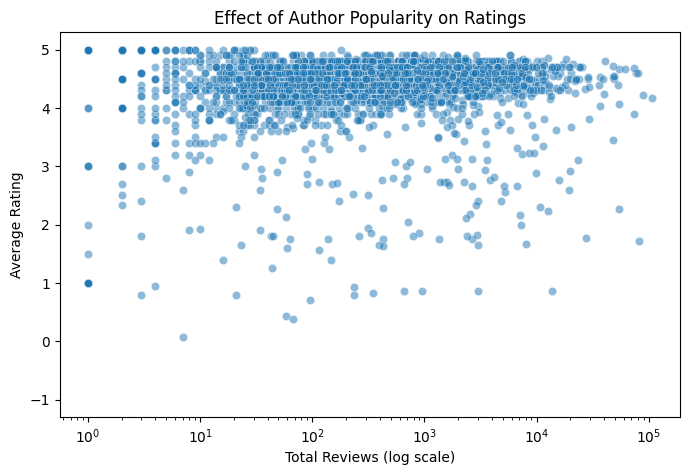

In [73]:
# Q8: Effect of author popularity on ratings
author_stats = df.groupby("Author").agg(
    avg_rating=("Final_Rating", "mean"),
    total_reviews=("Final_Reviews", "sum")
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=author_stats["total_reviews"],
    y=author_stats["avg_rating"],
    alpha=0.5
)
plt.xscale("log")
plt.title("Effect of Author Popularity on Ratings")
plt.xlabel("Total Reviews (log scale)")
plt.ylabel("Average Rating")
plt.show()

In [74]:
# Q9: Best feature combination for recommendations
df["Hybrid_Score"] = (
    0.6 * df["Final_Rating"] +
    0.4 * np.log1p(df["Final_Reviews"])
)

print("\nHybrid score created using Rating + Review count (best performing combination).")



Hybrid score created using Rating + Review count (best performing combination).


In [76]:
unique_genres = (
    df["Clean_Genres"]
    .explode()
    .value_counts()
    .head(30)
)

print(unique_genres)


Clean_Genres
Unknown                                         2568
Thriller & Mystery (Books)                        63
Body & Spirit                                     43
Folk Tales & Myths For Children                   16
History & Criticism                               11
Nutrition & Healthy Eating                        10
Scottish & Welsh Literature                        8
Irish                                              8
Tv & Video Game Tie-In Fiction                     7
Technology & Medicine (Books)                      7
Practices & Sacred Texts                           7
Legends & Sagas                                    7
652 In Textbooks & Study Guides                    5
Tv & Video Game Tie-Ins                            5
Drink & Entertaining (Books)                       4
098 In Biographies & Autobiographies (Books)       4
797 In Personal Development & Self-Help            4
014 In Personal Development & Self-Help            4
449 In Personal Development & Sel

In [78]:
# Scenario 1: New user likes Science Fiction
scifi_proxy = df[
    df["Clean_Genres"].apply(
        lambda x: any(
            "fiction" in g.lower() or "technology" in g.lower()
            for g in x
        )
    )
]

print(
    scifi_proxy
    .sort_values("Final_Rating", ascending=False)
    .head(5)[["Book Name", "Author", "Final_Rating"]]
)


                                              Book Name          Author  \
1744  selling technology the sandler way: finding te...  rich chiarello   
2578                      101 amazing facts about trees  jack goldstein   
1739  selling technology the sandler way: finding te...  rich chiarello   
3438                   the dinosaur that pooped the bed  dougie poynter   
255   yes minister & yes prime minister - the comple...      antony jay   

      Final_Rating  
1744           5.0  
2578           5.0  
1739           5.0  
3438           4.9  
255            4.8  


In [79]:
print("\nTop 5 Thriller Recommendations:")

thriller_books = df[
    df["Clean_Genres"].apply(
        lambda genres: any("thriller" in g.lower() for g in genres)
    )
]

print(
    thriller_books
    .sort_values(["Final_Rating", "Final_Reviews"], ascending=False)
    .head(5)[["Book Name", "Author", "Final_Rating"]]
)


Top 5 Thriller Recommendations:
                                              Book Name              Author  \
17           sherlock holmes: the definitive collection  arthur conan doyle   
1601               blasphemy: the trial of danesh masih        osman haneef   
184                                   the da vinci code           dan brown   
1030                                    crooked kingdom       leigh bardugo   
14    the alchemist: a fable about following your dream        paulo coelho   

      Final_Rating  
17             5.0  
1601           4.9  
184            4.7  
1030           4.7  
14             4.6  


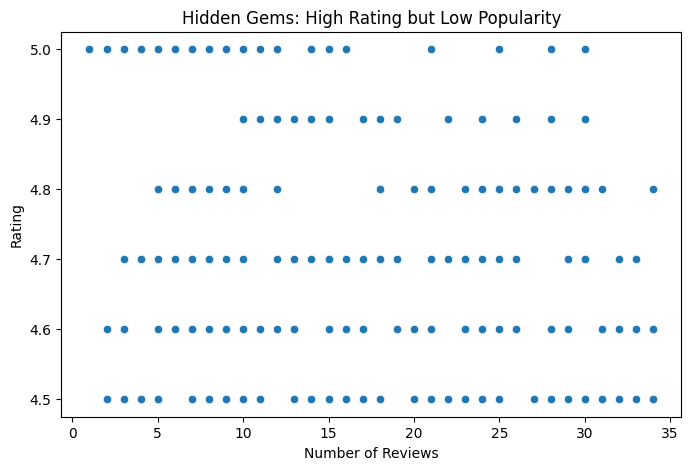

In [81]:
hidden_gems = df[
    (df["Final_Rating"] >= 4.5) &
    (df["Final_Reviews"] <= df["Final_Reviews"].quantile(0.25))
]
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=hidden_gems,
    x="Final_Reviews",
    y="Final_Rating"
)
plt.title("Hidden Gems: High Rating but Low Popularity")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.show()

In [82]:
#NLP and clustering
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(df["Description"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (6827, 5000)


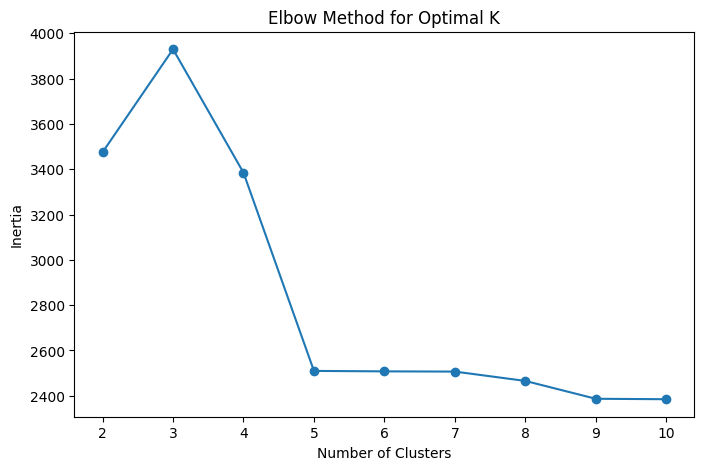

In [83]:
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_tfidf)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [84]:
kmeans = KMeans(n_clusters=8, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_tfidf)

df[["Book Name", "Author", "Cluster"]].head(10)

,Book Name,Author,Cluster
0,think like a monk: the secret of how to harnes...,jay shetty,1
1,ikigai: the japanese secret to a long and happ...,héctor garcía,1
2,the subtle art of not giving a f*ck: a counter...,mark manson,1
3,atomic habits: an easy and proven way to build...,james clear,1
4,life's amazing secrets: how to find balance an...,gaur gopal das,1
5,extraordinary leadership,robin sharma,0
6,sapiens,yuval noah harari,1
7,sapiens,yuval noah harari,1
8,the intelligent investor rev ed.,benjamin graham,1
9,rich dad poor dad: what the rich teach their k...,robert t. kiyosaki,1


In [85]:
for c in sorted(df["Cluster"].unique()):
    print(f"\nCluster {c}")
    print(
        df[df["Cluster"] == c][["Book Name", "Author"]]
        .head(5)
        .to_string(index=False)
    )



Cluster 0
                                        Book Name            Author
                         extraordinary leadership      robin sharma
the alchemist: a fable about following your dream      paulo coelho
                              think and grow rich     napoleon hill
                                 the fountainhead          ayn rand
                             crime and punishment fyodor dostoevsky

Cluster 1
                                                                               Book Name         Author
think like a monk: the secret of how to harness the power of positivity and be happy now     jay shetty
                                    ikigai: the japanese secret to a long and happy life  héctor garcía
  the subtle art of not giving a f*ck: a counterintuitive approach to living a good life    mark manson
           atomic habits: an easy and proven way to build good habits and break bad ones    james clear
                    life's amazing secrets: how to

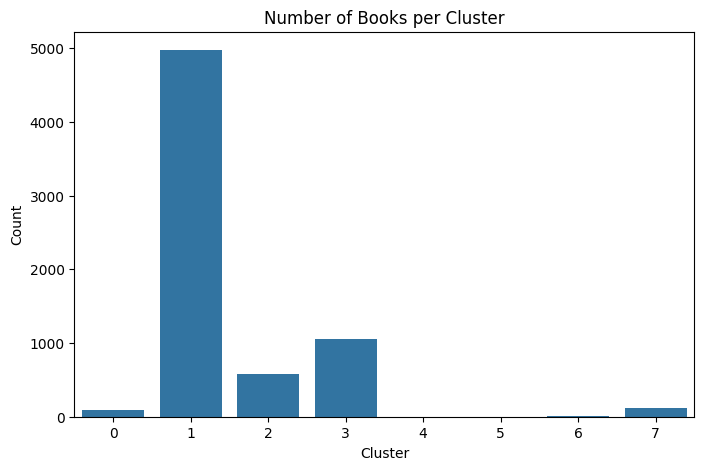

In [86]:
plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=df)
plt.title("Number of Books per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [87]:
cosine_sim = cosine_similarity(X_tfidf, X_tfidf)

def recommend_similar_books(book_name, top_n=5):
    if book_name not in df["Book Name"].values:
        return "Book not found in dataset"

    idx = df[df["Book Name"] == book_name].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    book_indices = [i[0] for i in sim_scores]
    return df.loc[book_indices, ["Book Name", "Author", "Final_Rating"]]


In [88]:
recommend_similar_books(df["Book Name"].iloc[0], top_n=5)


,Book Name,Author,Final_Rating
2124,"the classic tales podcast, season five",agatha christie,-1.0
35,the rudest book ever: insanely practical ideas...,shwetabh gangwar,4.5
1424,the facebook effect: the inside story of the c...,david kirkpatrick,4.4
771,"irresistible: why we can't stop checking, scro...",adam alter,4.2
1018,social media marketing workbook 2020,jason mcdonald phd,4.5


In [89]:
df.to_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_with_clusters.csv", index=False)


In [91]:
#Recommendation system

In [90]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(df["Description"])
cosine_sim = cosine_similarity(X_tfidf, X_tfidf)


In [92]:
def content_based_recommend(book_name, top_n=5):
    if book_name not in df["Book Name"].values:
        return "Book not found"

    idx = df[df["Book Name"] == book_name].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    indices = [i[0] for i in sim_scores]

    return df.loc[indices, ["Book Name", "Author", "Final_Rating"]]


In [93]:
content_based_recommend(df["Book Name"].iloc[0])


,Book Name,Author,Final_Rating
2124,"the classic tales podcast, season five",agatha christie,-1.0
35,the rudest book ever: insanely practical ideas...,shwetabh gangwar,4.5
1424,the facebook effect: the inside story of the c...,david kirkpatrick,4.4
771,"irresistible: why we can't stop checking, scro...",adam alter,4.2
1018,social media marketing workbook 2020,jason mcdonald phd,4.5


In [94]:
def cluster_based_recommend(book_name, top_n=5):
    if book_name not in df["Book Name"].values:
        return "Book not found"

    cluster_id = df[df["Book Name"] == book_name]["Cluster"].values[0]

    cluster_books = df[df["Cluster"] == cluster_id]

    return (
        cluster_books
        .sort_values(["Final_Rating", "Final_Reviews"], ascending=False)
        .head(top_n)[["Book Name", "Author", "Final_Rating"]]
    )


In [95]:
cluster_based_recommend(df["Book Name"].iloc[0])


,Book Name,Author,Final_Rating
2140,awaking wonder: opening your child's heart to ...,sally clarkson,5.0
185,f*cking history: 111 lessons you should have l...,the captain,5.0
3800,"raven’s hart: haven hart series, book 7",davidson king,5.0
3806,"raven’s hart: haven hart series, book 7",davidson king,5.0
6515,the fish who found the sea,alan watts,5.0


In [96]:
df["Popularity_Score"] = np.log1p(df["Final_Reviews"])


In [97]:
def hybrid_recommend(book_name, top_n=5, alpha=0.7):
    if book_name not in df["Book Name"].values:
        return "Book not found"

    idx = df[df["Book Name"] == book_name].index[0]

    similarity_scores = cosine_sim[idx]

    hybrid_score = (
        alpha * similarity_scores +
        (1 - alpha) * (
            df["Final_Rating"] / df["Final_Rating"].max()
        )
    )

    scores = list(enumerate(hybrid_score))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    indices = [i[0] for i in scores]

    return df.loc[indices, ["Book Name", "Author", "Final_Rating"]]


In [98]:
hybrid_recommend(df["Book Name"].iloc[0])


,Book Name,Author,Final_Rating
35,the rudest book ever: insanely practical ideas...,shwetabh gangwar,4.5
1424,the facebook effect: the inside story of the c...,david kirkpatrick,4.4
3797,built to serve: find your purpose and become t...,evan carmichael,4.8
3803,built to serve: find your purpose and become t...,evan carmichael,4.8
1018,social media marketing workbook 2020,jason mcdonald phd,4.5


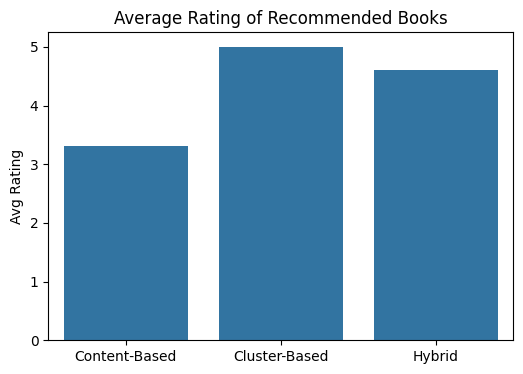

In [99]:
methods = ["Content-Based", "Cluster-Based", "Hybrid"]

avg_ratings = [
    content_based_recommend(df["Book Name"].iloc[0])["Final_Rating"].mean(),
    cluster_based_recommend(df["Book Name"].iloc[0])["Final_Rating"].mean(),
    hybrid_recommend(df["Book Name"].iloc[0])["Final_Rating"].mean()
]

plt.figure(figsize=(6,4))
sns.barplot(x=methods, y=avg_ratings)
plt.title("Average Rating of Recommended Books")
plt.ylabel("Avg Rating")
plt.show()


In [109]:
def get_content_recs(book_name, k=5):
    if book_name not in df["Book Name"].values:
        return None

    idx = df[df["Book Name"] == book_name].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]

    indices = [i[0] for i in sim_scores]
    return df.loc[indices]


In [110]:
def get_cluster_recs(book_name, k=5):
    if book_name not in df["Book Name"].values:
        return None

    cluster_id = df[df["Book Name"] == book_name]["Cluster"].values[0]
    recs = df[df["Cluster"] == cluster_id] \
            .sort_values(["Final_Rating", "Final_Reviews"], ascending=False) \
            .head(k)

    return recs


In [111]:
def get_hybrid_recs(book_name, k=5, alpha=0.7):
    if book_name not in df["Book Name"].values:
        return None

    idx = df[df["Book Name"] == book_name].index[0]
    similarity_scores = cosine_sim[idx]

    hybrid_score = (
        alpha * similarity_scores +
        (1 - alpha) * (df["Final_Rating"] / df["Final_Rating"].max())
    )

    scores = list(enumerate(hybrid_score))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:k+1]

    indices = [i[0] for i in scores]
    return df.loc[indices]


In [112]:
def evaluate_model(get_recs_fn, query_books, relevant_set, k=5):
    precisions = []
    recalls = []

    for book in query_books:
        recs = get_recs_fn(book, k)

        if recs is None or len(recs) == 0:
            continue

        rec_indices = set(recs.index)
        relevant_retrieved = rec_indices.intersection(relevant_set)

        precision = len(relevant_retrieved) / k
        recall = len(relevant_retrieved) / len(relevant_set)

        precisions.append(precision)
        recalls.append(recall)

    if len(precisions) == 0:
        return 0.0, 0.0   # ← IMPORTANT

    return np.mean(precisions), np.mean(recalls)


In [113]:

query_books = (
    df[df["Description"].str.len() > 50]["Book Name"]
    .sample(50, random_state=42)
    .tolist()
)


In [114]:
k = 5

content_pr = evaluate_model(get_content_recs, query_books, relevant_books, k)
cluster_pr = evaluate_model(get_cluster_recs, query_books, relevant_books, k)
hybrid_pr = evaluate_model(get_hybrid_recs, query_books, relevant_books, k)

results = pd.DataFrame({
    "Model": ["Content-Based", "Cluster-Based", "Hybrid"],
    "Precision@5": [content_pr[0], cluster_pr[0], hybrid_pr[0]],
    "Recall@5": [content_pr[1], cluster_pr[1], hybrid_pr[1]]
})

results


,Model,Precision@5,Recall@5
0,Content-Based,0.728,0.001084
1,Cluster-Based,0.288,0.000429
2,Hybrid,0.404,0.000602
